# Notebook 5 — Comparación Final de Modelos
**Objetivo:** Comparar todos los modelos (LSTM, BiGRU, Conv1D+BiLSTM) en ambos datasets y extraer conclusiones sobre el mejor enfoque para clasificación de sentimiento en español.

## 1. Setup y Carga de Métricas

In [21]:
rows = []
for res in all_results:
    model_family = res['config'].split('_')[0]
    rows.append({
        "Familia":   model_family,
        "Config":    res['config'],
        "Dataset":   res['dataset'],
        "Accuracy":  res['metrics']['accuracy'],
        "Precision": res['metrics']['precision'],
        "Recall":    res['metrics']['recall'],
        "F1-Score":  res['metrics']['f1'],
        "ROC-AUC":   res['metrics']['roc_auc'],
        "Params":    res.get('params', 0),
    })

df_all = pd.DataFrame(rows)

# Formatear para display
df_display = df_all.copy()
for col in ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.4f}")
df_display["Params"] = df_display["Params"].map(lambda x: f"{x:,}")

print("\n" + "="*80)
print("  RESULTADOS COMPLETOS — TODOS LOS MODELOS")
print("="*80)
display(df_display)

# Guardar CSV
path = os.path.join(DIRS["metrics"], "ALL_models_comparison.csv")
df_all.to_csv(path, index=False)
print(f"\n✅ Guardada en: {path}")


  RESULTADOS COMPLETOS — TODOS LOS MODELOS


,Familia,Config,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Params
0,LSTM,LSTM_C1_Simple,balanced,0.9585,0.9398,0.9542,0.9470,0.9881,"1,189,249"
1,LSTM,LSTM_C2_Medium,balanced,0.9585,0.9398,0.9542,0.9470,0.9848,"2,448,129"
2,LSTM,LSTM_C3_Stacked,balanced,0.9436,0.9179,0.9389,0.9283,0.9873,"2,495,489"
3,LSTM,LSTM_C4_Deep,balanced,0.9525,0.9137,0.9695,0.9407,0.9872,"5,404,929"
4,LSTM,LSTM_C1_Simple,big_ahr,0.9577,0.9758,0.9727,0.9743,0.9824,"1,315,137"
5,LSTM,LSTM_C2_Medium,big_ahr,0.9543,0.9787,0.9654,0.9720,0.9797,"2,699,905"
6,LSTM,LSTM_C3_Stacked,big_ahr,0.9612,0.9759,0.9769,0.9764,0.9831,"2,747,265"
7,LSTM,LSTM_C4_Deep,big_ahr,0.9620,0.9769,0.9769,0.9769,0.9840,"5,908,481"
8,BiGRU,BiGRU_C1_Simple,balanced,0.9925,0.9852,1.0000,0.9926,0.9999,"1,208,193"
9,BiGRU,BiGRU_C2_Medium,balanced,0.9907,0.9888,0.9925,0.9907,0.9999,"2,522,881"



✅ Guardada en: results\metrics\ALL_models_comparison.csv


## 3. Gráficas de Comparación Global

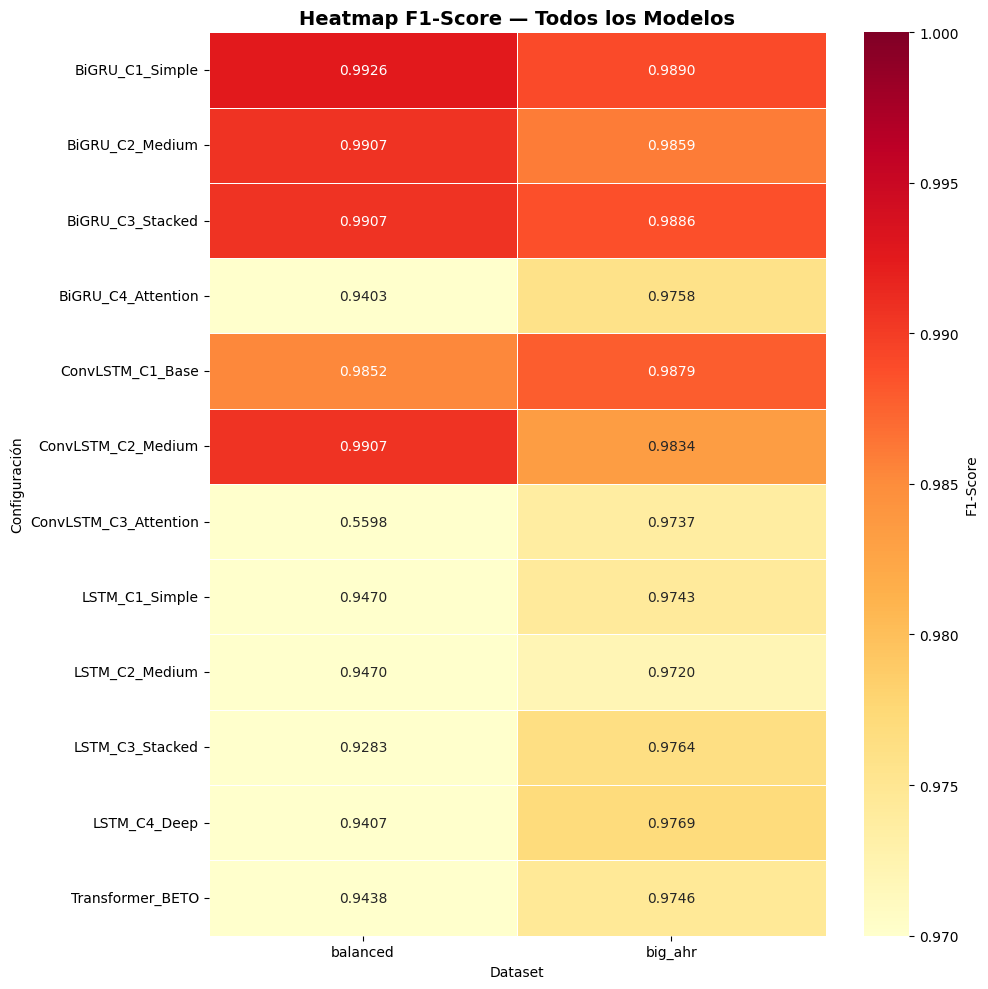

In [22]:
# ── 3.1 Heatmap de F1-Score ──────────────────────────────
pivot_f1 = df_all.pivot_table(index="Config", columns="Dataset", values="F1-Score")
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0.97, vmax=1.0,
            cbar_kws={'label': 'F1-Score'})
ax.set_title("Heatmap F1-Score — Todos los Modelos", fontsize=14, fontweight='bold')
ax.set_xlabel("Dataset"); ax.set_ylabel("Configuración")
plt.xticks(rotation=0); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_f1_heatmap.png"), dpi=150)
plt.show()

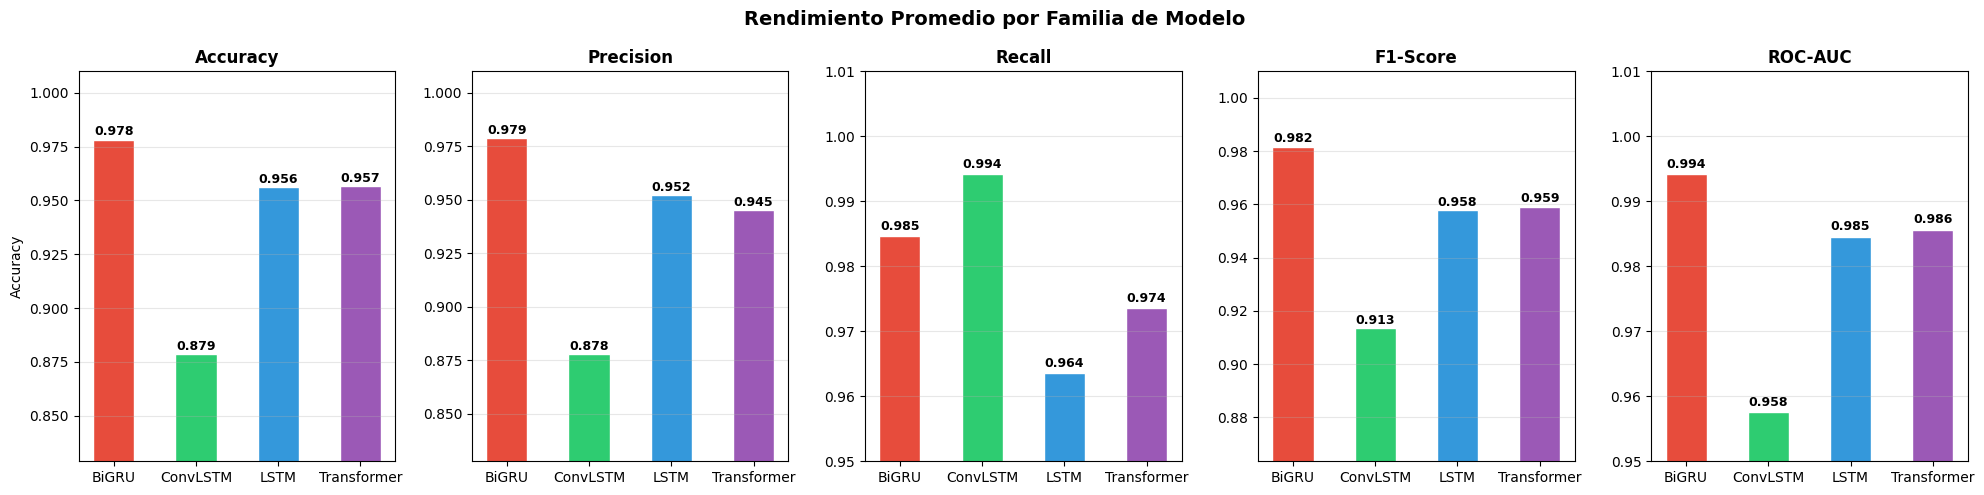

In [23]:
# ── 3.2 Barplot por familia (promedio ambos datasets) ────
metrics_cols = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
df_avg = df_all.groupby("Familia")[metrics_cols].mean().reset_index()

fig, axes = plt.subplots(1, len(metrics_cols), figsize=(20, 5))
fig.suptitle("Rendimiento Promedio por Familia de Modelo", fontsize=14, fontweight='bold')
colors_map = {"LSTM": "#3498db", "BiGRU": "#e74c3c", "ConvLSTM": "#2ecc71", "Transformer": "#9b59b6"}
colors = [colors_map.get(fam, "gray") for fam in df_avg["Familia"]]
for ax, metric in zip(axes, metrics_cols):
    bars = ax.bar(df_avg["Familia"], df_avg[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontweight='bold')
    min_val = df_avg[metric].min()
    ymin = max(0.0, min_val - 0.05) if min_val < 0.95 else 0.95
    ax.set_ylim(ymin, 1.01)
    ax.set_ylabel(metric if metric == "Accuracy" else "")
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_avg[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_avg_by_family.png"), dpi=150)
plt.show()

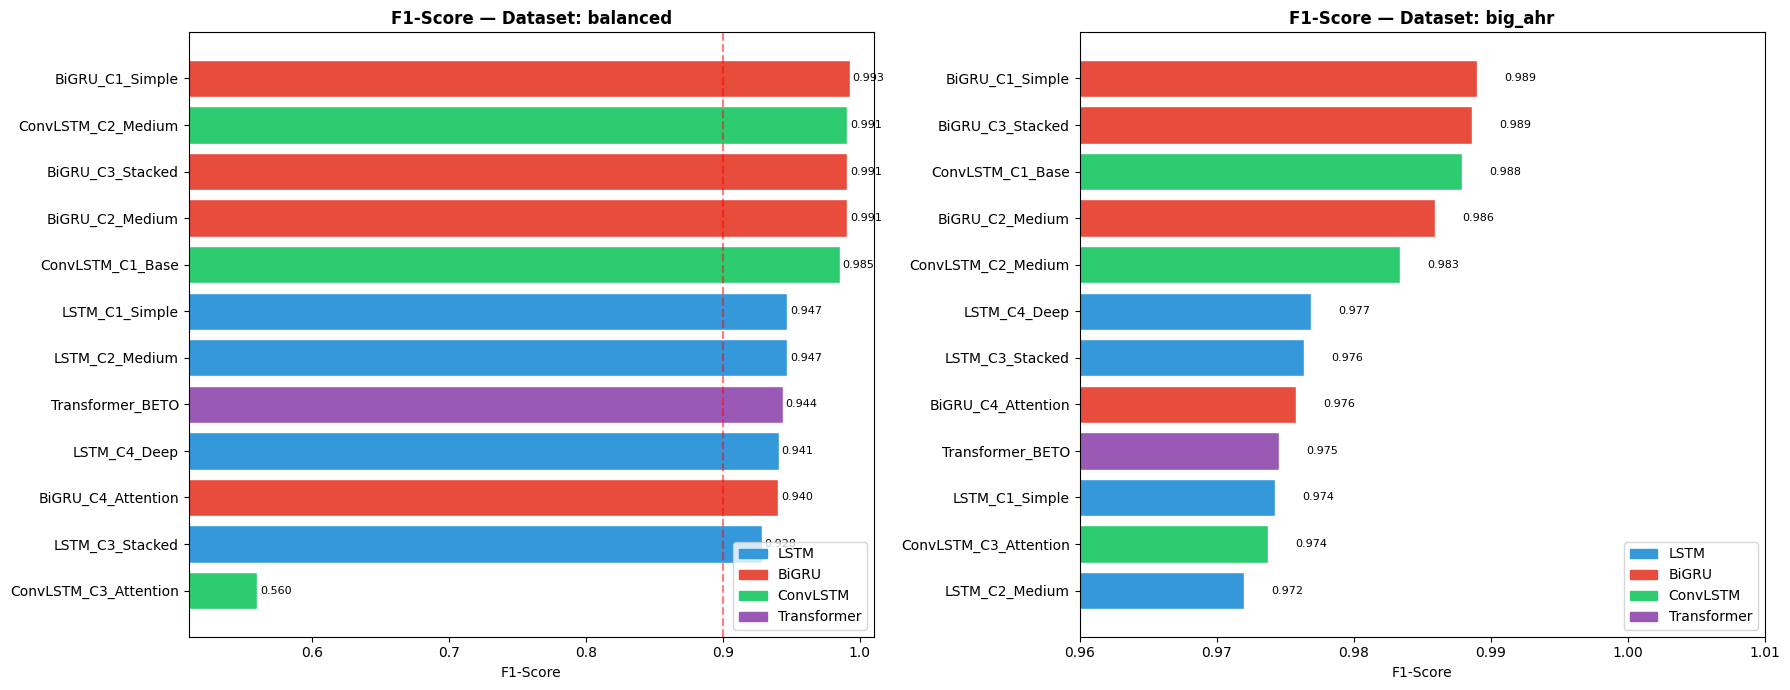

In [24]:
# ── 3.3 Comparación por dataset ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, ds in zip(axes, ["balanced","big_ahr"]):
    sub = df_all[df_all.Dataset == ds].sort_values("F1-Score", ascending=True)
    colors_map = {"LSTM":"#3498db","BiGRU":"#e74c3c","ConvLSTM":"#2ecc71","Transformer":"#9b59b6"}
    bar_colors = [colors_map.get(r.Familia,"gray") for _, r in sub.iterrows()]
    bars = ax.barh(sub["Config"], sub["F1-Score"], color=bar_colors, edgecolor='white')
    ax.set_title(f"F1-Score — Dataset: {ds}", fontsize=12, fontweight='bold')
    min_f1 = sub["F1-Score"].min()
    xmin = max(0.0, min_f1 - 0.05) if min_f1 < 0.96 else 0.96
    ax.set_xlabel("F1-Score"); ax.set_xlim(xmin, 1.01)
    ax.axvline(0.9, color='red', linestyle='--', alpha=0.5, label='F1=0.90')
    for bar, val in zip(bars, sub["F1-Score"]):
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va='center', fontsize=8)
    from matplotlib.patches import Patch
    legend = [Patch(color=v, label=k) for k, v in colors_map.items()]
    ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_f1_by_dataset.png"), dpi=150)
plt.show()

## 4. Top Modelos por Dataset

In [25]:
print("\n" + "="*65)
print("  TOP 3 MODELOS POR DATASET (según F1-Score)")
print("="*65)
for ds in ["balanced", "big_ahr"]:
    sub = df_all[df_all.Dataset==ds].sort_values("F1-Score", ascending=False).head(3)
    print(f"\n  Dataset: {ds.upper()}")
    print(f"  {'Rank':<5} {'Modelo':<35} {'F1':>7} {'AUC':>8} {'Params':>12}")
    print("  " + "-"*67)
    for rank, (_, row) in enumerate(sub.iterrows(), 1):
        print(f"  {rank:<5} {row['Config']:<35} {row['F1-Score']:>7.4f} "
              f"{row['ROC-AUC']:>8.4f} {int(row['Params']):>12,}")


  TOP 3 MODELOS POR DATASET (según F1-Score)

  Dataset: BALANCED
  Rank  Modelo                                   F1      AUC       Params
  -------------------------------------------------------------------
  1     BiGRU_C1_Simple                      0.9926   0.9999    1,208,193
  2     ConvLSTM_C2_Medium                   0.9907   0.9996    2,613,441
  3     BiGRU_C3_Stacked                     0.9907   0.9998    2,640,385

  Dataset: BIG_AHR
  Rank  Modelo                                   F1      AUC       Params
  -------------------------------------------------------------------
  1     BiGRU_C1_Simple                      0.9890   0.9948    1,334,081
  2     BiGRU_C3_Stacked                     0.9886   0.9949    2,892,161
  3     ConvLSTM_C1_Base                     0.9879   0.9947    1,362,817


## 5. Análisis de Hiperparámetros

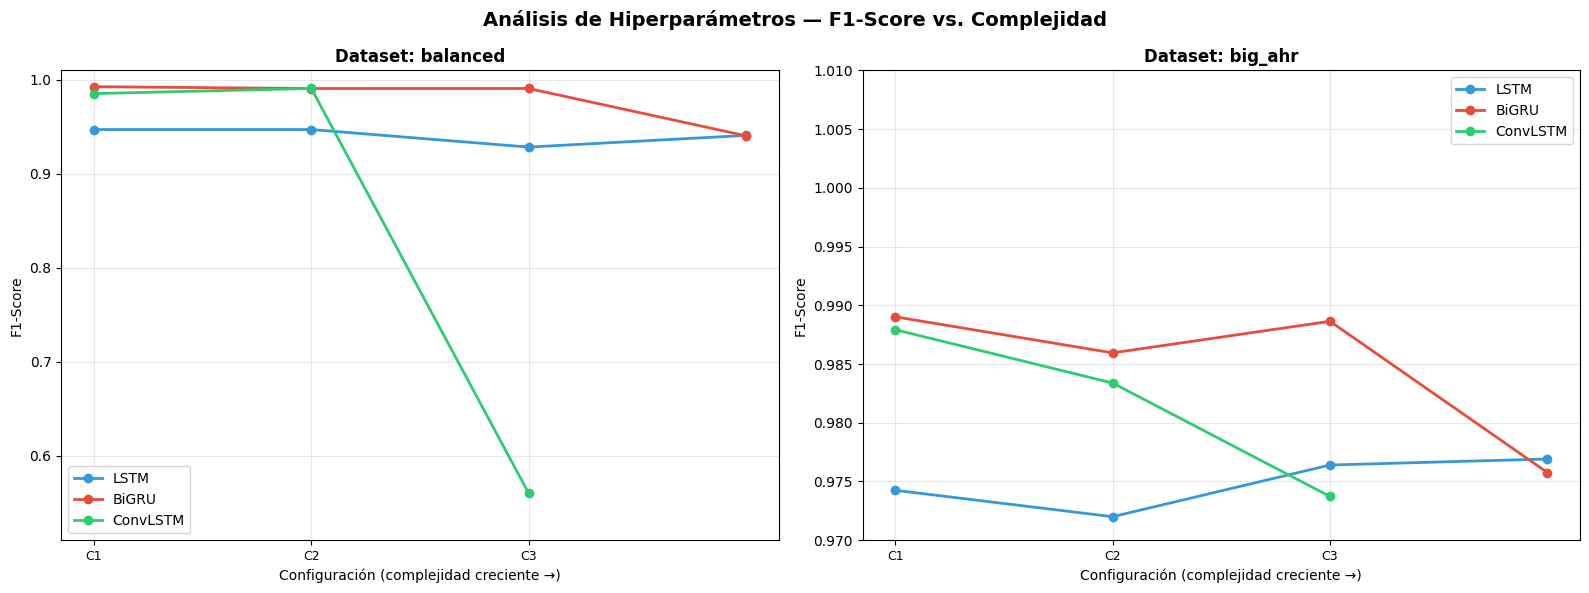

In [26]:
# Evolución del F1-Score por nivel de complejidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Análisis de Hiperparámetros — F1-Score vs. Complejidad",
             fontsize=14, fontweight='bold')

families = {"LSTM": "#3498db", "BiGRU": "#e74c3c", "ConvLSTM": "#2ecc71"}

for ax, ds in zip(axes, ["balanced","big_ahr"]):
    sub = df_all[df_all.Dataset == ds]
    for family, color in families.items():
        fam_data = sub[sub.Familia == family].sort_values("Config")
        configs  = [c.split("_C")[1].split("_")[0] for c in fam_data["Config"]]
        configs  = [f"C{c}" for c in configs]
        ax.plot(range(len(fam_data)), fam_data["F1-Score"],
                marker='o', linewidth=2, color=color, label=family)
        ax.set_xticks(range(len(fam_data)))
        ax.set_xticklabels(configs[:len(fam_data)], fontsize=9)

    ax.set_title(f"Dataset: {ds}", fontweight='bold')
    ax.set_xlabel("Configuración (complejidad creciente →)")
    min_f1 = sub["F1-Score"].min()
    ymin = max(0.0, min_f1 - 0.05) if min_f1 < 0.97 else 0.97
    ax.set_ylabel("F1-Score"); ax.set_ylim(ymin, 1.01)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_hyperparam_analysis.png"), dpi=150)
plt.show()

## 6. Eficiencia: F1-Score vs. Parámetros

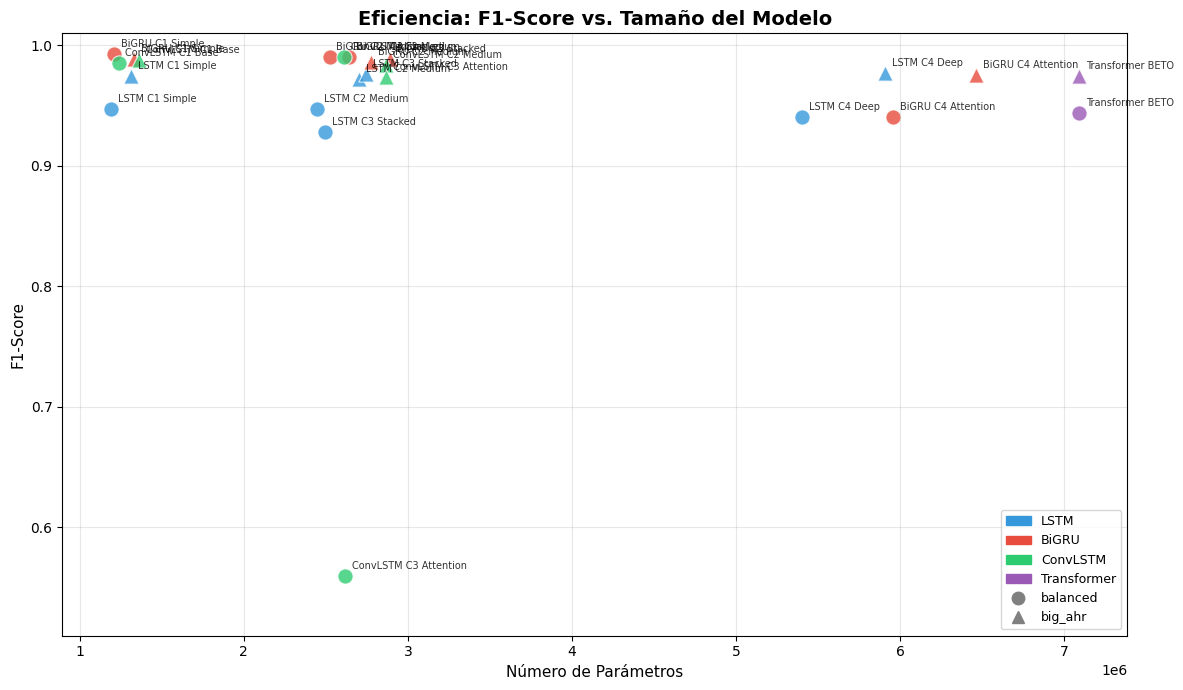

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))
colors_map = {"LSTM":"#3498db","BiGRU":"#e74c3c","ConvLSTM":"#2ecc71","Transformer":"#9b59b6"}
markers    = {"balanced":"o","big_ahr":"^"}

for ds in ["balanced","big_ahr"]:
    sub = df_all[df_all.Dataset == ds]
    for _, row in sub.iterrows():
        clr = colors_map.get(row['Familia'],'gray')
        ax.scatter(row['Params'], row['F1-Score'],
                   c=clr, marker=markers[ds], s=120, alpha=0.8,
                   edgecolors='white', linewidth=0.8)
        ax.annotate(row['Config'].replace("_"," "),
                    (row['Params'], row['F1-Score']),
                    textcoords="offset points", xytext=(5,5), fontsize=7, alpha=0.8)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_family = [Patch(color=v, label=k) for k, v in colors_map.items()]
legend_ds     = [Line2D([0],[0], marker=m, color='gray', linestyle='', label=ds, markersize=9)
                 for ds, m in markers.items()]
ax.legend(handles=legend_family+legend_ds, loc='lower right', fontsize=9)
ax.set_xlabel("Número de Parámetros", fontsize=11)
ax.set_ylabel("F1-Score", fontsize=11)
ax.set_title("Eficiencia: F1-Score vs. Tamaño del Modelo", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
min_f1 = df_all["F1-Score"].min()
ymin = max(0.0, min_f1 - 0.05) if min_f1 < 0.97 else 0.97
ax.set_ylim(ymin, 1.01)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_efficiency_scatter.png"), dpi=150)
plt.show()

## 7. Curvas de Entrenamiento — Mejores Modelos

  Mejor modelo clásico [balanced]: BiGRU_C1_Simple (F1=0.9926)
  Mejor modelo clásico [big_ahr]: BiGRU_C1_Simple (F1=0.9890)


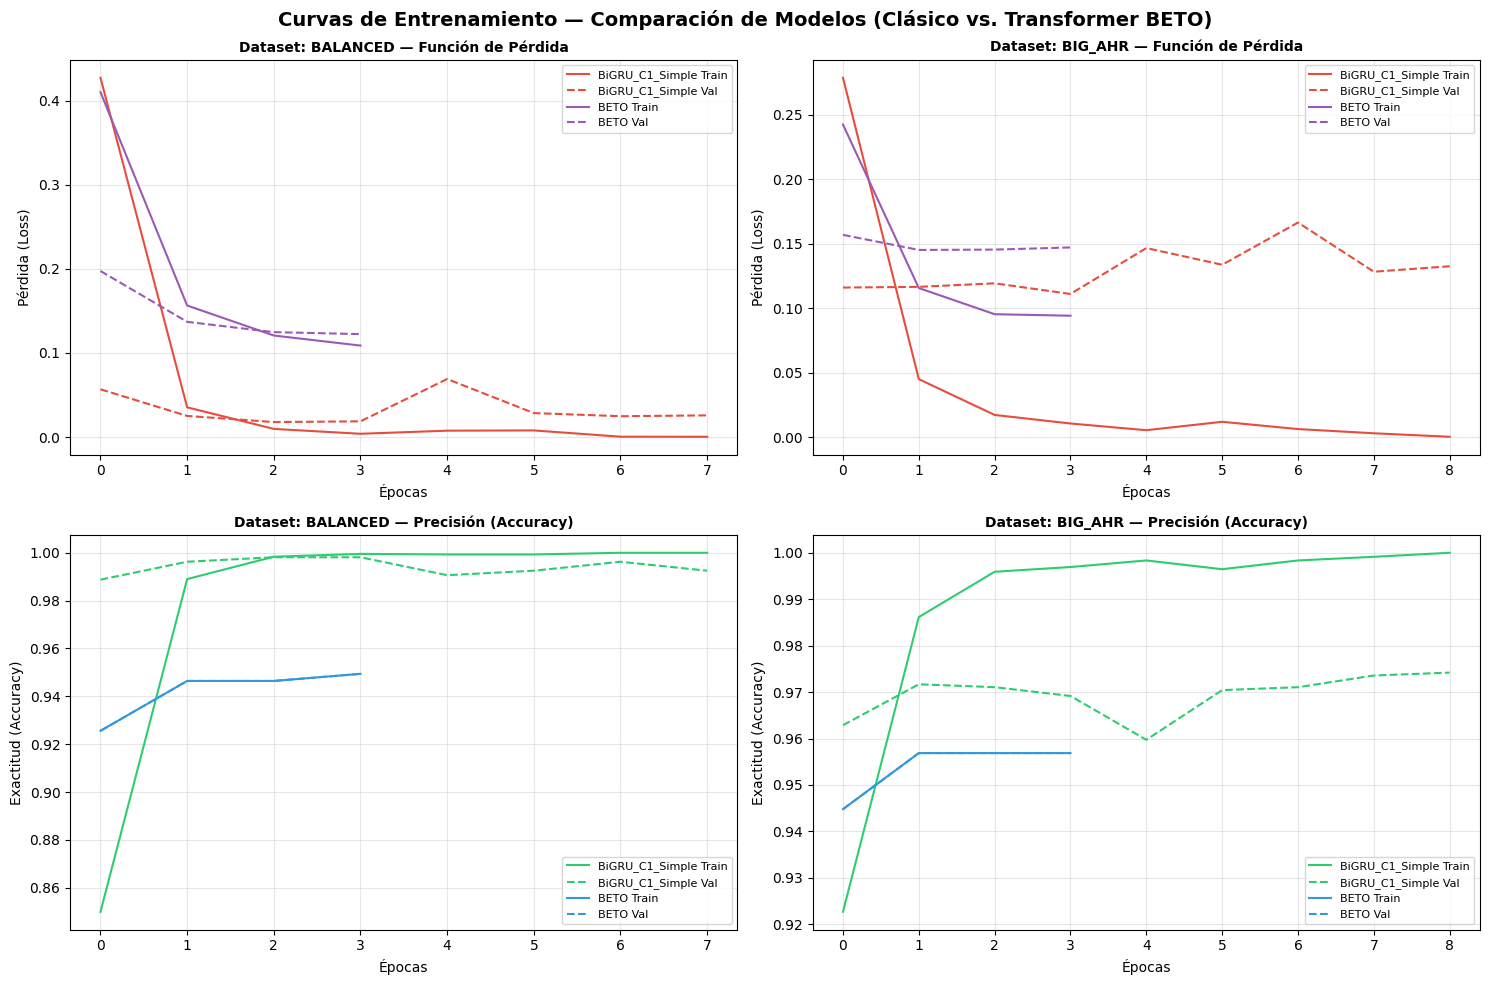

In [28]:
# Extraer mejores configs clásicas por dataset
best_classical_configs = {}
for ds in ["balanced","big_ahr"]:
    sub  = df_all[(df_all.Dataset==ds) & (df_all.Familia != "Transformer")].sort_values("F1-Score", ascending=False)
    best = sub.iloc[0]
    best_classical_configs[ds] = {"config": best["Config"], "family": best["Familia"]}
    print(f"  Mejor modelo clásico [{ds}]: {best['Config']} (F1={best['F1-Score']:.4f})")

# Recuperar historiales de los resultados
def get_history(all_results_list, config_name, dataset_name):
    for r in all_results_list:
        if r['config'] == config_name and r['dataset'] == dataset_name:
            h = r.get('history', {})
            if isinstance(h, list):
                # Convert HF log history to Keras-like dict of lists aligned by epoch
                max_epoch = int(max(log.get('epoch', 0) for log in h) + 0.99)
                keras_h = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
                for ep in range(1, max_epoch + 1):
                    ep_losses = [log['loss'] for log in h if 'loss' in log and ep - 1 < log['epoch'] <= ep]
                    if ep_losses:
                        keras_h['loss'].append(sum(ep_losses) / len(ep_losses))
                    else:
                        keras_h['loss'].append(0.0)
                    
                    ep_eval = [log for log in h if 'eval_loss' in log and ep - 0.5 < log['epoch'] <= ep + 0.5]
                    if ep_eval:
                        ep_eval.sort(key=lambda x: abs(x['epoch'] - ep))
                        keras_h['val_loss'].append(ep_eval[0]['eval_loss'])
                        keras_h['val_accuracy'].append(ep_eval[0].get('eval_accuracy', 0.0))
                    else:
                        keras_h['val_loss'].append(0.0)
                        keras_h['val_accuracy'].append(0.0)
                keras_h['accuracy'] = list(keras_h['val_accuracy'])
                return keras_h
            return h
    return {}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Curvas de Entrenamiento — Comparación de Modelos (Clásico vs. Transformer BETO)", fontsize=14, fontweight='bold')

src_classical = {"LSTM": lstm_results, "BiGRU": bigru_results, "ConvLSTM": convlstm_results}

for col, ds in enumerate(["balanced", "big_ahr"]):
    # 1. Obtener historial del mejor clásico
    info_class = best_classical_configs[ds]
    cfg_class = info_class["config"]
    fam_class = info_class["family"]
    hist_class = get_history(src_classical[fam_class], cfg_class, ds)
    
    # 2. Obtener historial del Transformer BETO
    hist_trans = get_history(transformer_results, "Transformer_BETO", ds)
    
    # --- Graficar Pérdida (Loss) ---
    if hist_class:
        axes[0][col].plot(hist_class['loss'],     color='#e74c3c', label=f'{cfg_class} Train')
        axes[0][col].plot(hist_class['val_loss'], color='#e74c3c', linestyle='--', label=f'{cfg_class} Val')
    if hist_trans:
        axes[0][col].plot(hist_trans['loss'],     color='#9b59b6', label='BETO Train')
        axes[0][col].plot(hist_trans['val_loss'], color='#9b59b6', linestyle='--', label='BETO Val')
        
    axes[0][col].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[1][col].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[0][col].set_title(f"Dataset: {ds.upper()} — Función de Pérdida", fontsize=10, fontweight='bold')
    axes[0][col].set_xlabel("Épocas")
    axes[0][col].set_ylabel("Pérdida (Loss)")
    axes[0][col].legend(fontsize=8)
    axes[0][col].grid(alpha=0.3)
    
    # --- Graficar Precisión (Accuracy) ---
    if hist_class:
        axes[1][col].plot(hist_class['accuracy'],     color='#2ecc71', label=f'{cfg_class} Train')
        axes[1][col].plot(hist_class['val_accuracy'], color='#2ecc71', linestyle='--', label=f'{cfg_class} Val')
    if hist_trans:
        axes[1][col].plot(hist_trans['accuracy'],     color='#3498db', label='BETO Train')
        axes[1][col].plot(hist_trans['val_accuracy'], color='#3498db', linestyle='--', label='BETO Val')
        
    axes[1][col].set_title(f"Dataset: {ds.upper()} — Precisión (Accuracy)", fontsize=10, fontweight='bold')
    axes[1][col].set_xlabel("Épocas")
    axes[1][col].set_ylabel("Exactitud (Accuracy)")
    axes[1][col].legend(fontsize=8)
    axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "FINAL_best_training_curves.png"), dpi=150)
plt.show()